# 03: Analyze Stadium & Attendance Data

Produces the visualizations for the stadium/infrastructure half of the project:

1. A map of current stadiums, sized by capacity and colored by which league(s) play there.
2. How full each stadium is relative to its capacity.
3. Average NWSL home attendance by team.
4. NWSL average home attendance by season, by team.
5. Which teams are driving (or dragging down) league-wide attendance growth, and which specific matchups draw the biggest rivalry premium.
6. When (day of week, month) fans actually show up, and whether shared stadiums favor the MLS tenant.
7. Whether on-field success (points per game) predicts attendance, and which teams over/under-draw relative to their record -- for NWSL and for MLS.
8. Whether a new stadium coincides with a bump in attendance.
9. Whether NWSL is closing the public-interest gap with MLS.
10. Whether metro market size predicts attendance -- for NWSL and for MLS.
11. Confounding checks, then one regression: what actually predicts attendance, including whether distance from downtown matters the way a cited study claims it does.

Uses the shared color theme in `plot_theme.py` so every chart in this repo reads as part of the same project.

**Inputs:** `data/processed/stadiums.csv`, `teams_clean.csv`, `games_clean.csv`, `star_player_seasons.csv`, `data/raw/time_series_mens_womens.csv` (metro population is a hand-built lookup, not a pulled dataset)
**Outputs:** figures saved to `output/`

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import os
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from plot_theme import style_plotly_fig, NWSL_SEQUENTIAL

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
OUTPUT_DIR = os.path.join("..", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

stadiums = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "stadiums.csv"))
teams = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "teams_clean.csv"))
games = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "games_clean.csv"))
star_player_seasons = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "star_player_seasons.csv"))

print(f"Loaded: stadiums {stadiums.shape}, teams {teams.shape}, games {games.shape}, "
      f"star_player_seasons {star_player_seasons.shape}")


def fit_trend(x, y):
    """Slope/intercept via sklearn LinearRegression, r via numpy.corrcoef --
    used everywhere in this notebook that a chart needs a trendline + Pearson r."""
    model = LinearRegression().fit(np.asarray(x).reshape(-1, 1), y)
    slope = model.coef_[0]
    intercept = model.intercept_
    r = np.corrcoef(x, y)[0, 1]
    return slope, intercept, r


Loaded: stadiums (57, 38), teams (50, 8), games (7283, 23), star_player_seasons (21, 6)


## Map: current stadiums by capacity and league

In [2]:
current_stadiums = stadiums[stadiums.primary_is_current == True].copy()
current_stadiums["capacity_clean"] = current_stadiums["capacity"].fillna(10000)

fig = px.scatter_map(
    current_stadiums,
    lat="latitude",
    lon="longitude",
    hover_name="stadium_name",
    color="competition",
    size="capacity_clean",
    size_max=20,
    zoom=3.2,
    map_style="open-street-map",
)

fig = style_plotly_fig(fig)
fig.update_layout(
    width=1000,
    height=600,
    margin={"r": 0, "t": 0, "l": 0, "b": 0},
    title={
        "text": "<b>MLS & NWSL Stadiums by Capacity</b>",
        "y": 0.95,
        "x": 0.02,
        "xanchor": "left",
        "yanchor": "top",
        "font": {"size": 20, "color": "#1b2430", "family": "Arial, sans-serif"},
    },
)

fig.write_image(os.path.join(OUTPUT_DIR, "stadiums_map_by_capacity.png"))
fig.show()


/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/1387250470.py:31: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "stadiums_map_by_capacity.png"))


## How full are the stadiums?

Raw attendance numbers don't say whether a team is filling its building or rattling around in it. Utilization = 2025 (last complete season) average home attendance / the venue's seating capacity.

**Note:** several NWSL teams are the *secondary* tenant of a football-sized venue shared with an MLS or NFL team (Gillette Stadium, Lumen Field, Dick's Sporting Goods Park, PayPal Park, Shell Energy Stadium). Those venues' listed capacity is the full bowl, but teams routinely curtain off upper sections for a smaller soccer crowd. So utilization for those five teams is a **lower bound**, not literally how empty the building looked on game day.

In [3]:
# 1. Current active NWSL teams and their 2025 average home attendance
active_teams_util = teams[(teams["league"] == "nwsl") & (teams["year_of_death"].isna())].copy()

nwsl_games_util = games[games["league"] == "nwsl"].dropna(subset=["attendance", "home_team_id"])
att_2025 = (
    nwsl_games_util[nwsl_games_util["season_name"] == 2025]
    .groupby("home_team_id")["attendance"]
    .mean()
    .rename("avg_attendance_2025")
)

# 2. Each team's CURRENT stadium: checking both primary AND secondary tenant slots.
# Many NWSL teams are secondary tenants, so have to look ip both
current_venues = stadiums[stadiums["primary_is_current"] | stadiums["secondary_is_current"]]
tenant_rows = []
for _, venue in current_venues.iterrows():
    if pd.notna(venue["primary_team_id"]) and venue["primary_is_current"]:
        tenant_rows.append({"team_id": venue["primary_team_id"], "stadium_name": venue["stadium_name"],
                             "capacity": venue["capacity"], "tenant_rank": "primary"})
    if pd.notna(venue["secondary_team_id"]) and venue["secondary_is_current"]:
        tenant_rows.append({"team_id": venue["secondary_team_id"], "stadium_name": venue["stadium_name"],
                             "capacity": venue["capacity"], "tenant_rank": "secondary"})
current_tenants = pd.DataFrame(tenant_rows)

utilization = (
    active_teams_util.merge(current_tenants, on="team_id", how="left")
    .merge(att_2025, left_on="team_id", right_index=True, how="left")
    .dropna(subset=["capacity", "avg_attendance_2025"])
)
utilization["utilization_pct"] = utilization["avg_attendance_2025"] / utilization["capacity"] * 100
utilization["shared_nfl_sized_venue"] = utilization["tenant_rank"] == "secondary"
utilization = utilization.sort_values("utilization_pct")

# 3. Plot: lollipop / dot chart, capped visually at 100% with a sellout reference line
fig = px.scatter(
    utilization,
    x="utilization_pct", y="team_name",
    color="shared_nfl_sized_venue",
    color_discrete_map={True: "#B23A72", False: "#1F9985"},
    hover_data={"stadium_name": True, "capacity": ":,", "avg_attendance_2025": ":,.0f",
                "shared_nfl_sized_venue": False, "utilization_pct": ":.0f"},
    labels={"utilization_pct": "2025 Avg. Attendance as % of Venue Capacity", "team_name": "Team",
            "shared_nfl_sized_venue": "Secondary tenant of a shared, football-sized venue"},
    title="<b>How Full Are the Stadiums? 2025 Attendance vs. Capacity</b>",
)
fig.update_traces(marker={"size": 13})
# Lollipop stems
for _, row in utilization.iterrows():
    fig.add_shape(
        type="line", x0=0, x1=row["utilization_pct"], y0=row["team_name"], y1=row["team_name"],
        line={"color": "#e3ddd3", "width": 2}, layer="below",
    )
fig.add_vline(x=100, line_width=1, line_dash="dash", line_color="gray")

fig = style_plotly_fig(fig)
fig.update_layout(
    height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10},
    legend={"orientation": "h", "y": -0.15, "x": 0.5, "xanchor": "center"},
)
# Reorder color-grouping
fig.update_yaxes(categoryorder="array", categoryarray=utilization["team_name"].tolist())
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_capacity_utilization.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/1946277795.py:62: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_capacity_utilization.png"))


## When do fans show up? Scheduling patterns

Initially saw massive attendence increase for Monday games, but after second look, these were all West Coast Sunday night games. To fix this, converting every game to its native time one. Most of those games were actually played on Monday. Not 100% fool-proof for daylight savings time, but mostly matches the NWSL's March-November season.

Even after the fix, a handful of dark "Monday" cells remain in the heatmap below -- checked those individually too, and they're real (Memorial Day games, and several Angel City FC prime-time Monday showcases that drew 15-22k), just a small sample of a few games rather than a broad weekly pattern. The hover on each cell shows the game count so you can tell a real pattern from a thin one.

In [4]:
# 1. Approximate local-time UTC offset per stadium (seasonal/DST offset, since NWSL plays
STATE_OFFSET = {
    "California": -7, "Washington": -7, "Oregon": -7,
    "Utah": -6, "Colorado": -6,
    "Texas": -5, "Kansas": -5, "Missouri": -5, "Illinois": -5,
    "Ohio": -4, "Kentucky": -4, "New Jersey": -4, "Pennsylvania": -4,
    "North Carolina": -4, "Florida": -4, "Maryland": -4, "Massachusetts": -4,
    "District of Columbia": -4, "New York": -4,
}
# A handful of stadiums have no city/province in the wiki-merged table, filled in by hand
STADIUM_OFFSET_OVERRIDE = {
    "Field of Legends": -5, "Northwestern Stadium": -5, "Snapdragon Stadium": -7,
    "CPKC Stadium": -5, "Jordan Field": -5, "Rochester Rinos Stadium": -4,
    "UW Medicine Pitch at Memorial Stadium": -7, "Osceola Heritage Park": -4,
    "Moda Field": -7, "Yurcak Field": -4,
}

stadium_offsets = stadiums[["stadium_id", "stadium_name", "province"]].copy()
stadium_offsets["utc_offset"] = (
    stadium_offsets["stadium_name"].map(STADIUM_OFFSET_OVERRIDE)
    .fillna(stadium_offsets["province"].map(STATE_OFFSET))
)

# 2. Convert each game to local kickoff time
schedule = games[games["league"] == "nwsl"].dropna(subset=["attendance", "stadium_id"]).merge(
    stadium_offsets[["stadium_id", "utc_offset"]], on="stadium_id", how="left",
)
n_dropped = schedule["utc_offset"].isna().sum()
schedule = schedule.dropna(subset=["utc_offset"])
schedule["date_time_utc"] = pd.to_datetime(schedule["date_time_utc"])
schedule["local_dt"] = schedule["date_time_utc"] + pd.to_timedelta(schedule["utc_offset"], unit="h")
schedule["day_of_week"] = schedule["local_dt"].dt.day_name()
schedule["month"] = schedule["local_dt"].dt.month_name()

print(f"Dropped {n_dropped} games at stadiums with no location metadata")

# 3. Heatmap: avg attendance by day-of-week x month (local time)
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = ["March", "April", "May", "June", "July", "August", "September", "October", "November"]

heat_pivot = schedule.pivot_table(index="day_of_week", columns="month", values="attendance", aggfunc="mean")
heat_pivot = heat_pivot.reindex(index=dow_order, columns=[m for m in month_order if m in heat_pivot.columns])
count_pivot = schedule.pivot_table(index="day_of_week", columns="month", values="game_id", aggfunc="count")
count_pivot = count_pivot.reindex(index=dow_order, columns=heat_pivot.columns)

fig = px.imshow(
    heat_pivot,
    color_continuous_scale=NWSL_SEQUENTIAL,
    aspect="auto",
    labels={"color": "Avg. Attendance", "x": "Month (local)", "y": "Day of Week (local)"},
    title="<b>When Do Fans Show Up? Attendance by Day of Week and Month</b>",
)
# Overlay game counts so a reader can see which cells are thin samples- playoffs, weekday rarities
fig.update_traces(
    customdata=count_pivot.values,
    hovertemplate="%{y}, %{x}<br>Avg. attendance: %{z:,.0f}<br>Games: %{customdata}<extra></extra>",
)
fig = style_plotly_fig(fig)
fig.update_layout(height=460, margin={"t": 60, "b": 40, "l": 10, "r": 10})
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_scheduling_heatmap.png"))
fig.show()

Dropped 39 games at stadiums with no location metadata


/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/2845591875.py:60: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_scheduling_heatmap.png"))


### Do shared stadiums prioritize the MLS tenant?

17 stadiums in the data have hosted both an MLS and an NWSL team at some point; 12 of them currently host a team from each league. At all but one, the MLS team is the **primary** (senior) tenant and the NWSL team is secondary. The one exception is Snapdragon Stadium, where San Diego Wave FC (2023) arrived before San Diego FC's MLS expansion team (2025).

Since both tenants play at the exact same venue, this comparison doesn't need local-time conversion. The question: does the NWSL tenant get pushed into the worse days/times while the MLS tenant gets the prime slots?

In [5]:
# 1. Current stadiums shared by both leagues
shared_stadiums = stadiums[
    (stadiums["competition"] == "both") & (stadiums["primary_is_current"] | stadiums["secondary_is_current"])
]
shared_stadium_ids = shared_stadiums["stadium_id"].tolist()

# 2. All games (any season) played at those stadiums, by either league (raw UTC)
shared_games = games[games["stadium_id"].isin(shared_stadium_ids) & games["league"].isin(["nwsl", "mls"])].copy()
shared_games["date_time_utc"] = pd.to_datetime(shared_games["date_time_utc"])
shared_games["day_of_week"] = shared_games["date_time_utc"].dt.day_name()

dow_share = (
    shared_games.groupby(["league", "day_of_week"]).size()
    .rename("games").reset_index()
)
dow_share["pct"] = dow_share["games"] / dow_share.groupby(dow_share["league"])["games"].transform("sum") * 100
dow_share["league_label"] = dow_share["league"].map({"nwsl": "NWSL (mostly secondary tenant)", "mls": "MLS (mostly primary tenant)"})

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig = px.bar(
    dow_share,
    x="day_of_week", y="pct", color="league_label",
    barmode="group",
    category_orders={"day_of_week": dow_order},
    color_discrete_map={"NWSL (mostly secondary tenant)": "#1F5FA8", "MLS (mostly primary tenant)": "#B23A72"},
    labels={"pct": "% of Games at Shared Stadiums", "day_of_week": "Day of Week (UTC)", "league_label": ""},
    title="<b>Kickoff Day-of-Week Mix at Shared Stadiums: NWSL vs. MLS</b>",
)
fig = style_plotly_fig(fig)
fig.update_layout(
    height=460, margin={"t": 60, "b": 40, "l": 10, "r": 10},
    legend={"orientation": "h", "y": -0.15, "x": 0.5, "xanchor": "center"},
)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_shared_stadium_scheduling.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/4240620837.py:35: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_shared_stadium_scheduling.png"))


**The data doesn't support the "MLS gets priority" hypothesis, at least not on day-of-week.** Potential for deeper analysis of prime-time slots.

## NWSL average home attendance by team

In [6]:
nwsl_games = games[games.league == "nwsl"].copy()
nwsl_teams = teams[teams.league == "nwsl"].copy()

# 1. Drop missing attendance rows
att_df = nwsl_games.dropna(subset=["attendance", "home_team_id"]).copy()

# 2. Merge with nwsl_teams to get team names
att_df = att_df.merge(
    nwsl_teams[["team_id", "team_name"]],
    left_on="home_team_id", right_on="team_id", how="left",
)

# 3. Group by team_name
team_summary = att_df.groupby("team_name").agg(
    avg_attendance=("attendance", "mean"),
    games_recorded=("game_id", "count"),
).reset_index()

# 4. Star recently-expanded teams (<=3 seasons) 
seasons_played = att_df.groupby("team_name")["season_name"].nunique()
team_summary["seasons_played"] = team_summary["team_name"].map(seasons_played)
team_summary["recent_expansion"] = team_summary["seasons_played"] <= 3
team_summary["team_label"] = team_summary["team_name"] + team_summary["recent_expansion"].map({True: " ★", False: ""})

# 5. Plot
fig = px.bar(
    team_summary.sort_values(by="avg_attendance", ascending=True),
    x="avg_attendance",
    y="team_label",
    orientation="h",
    color="avg_attendance",
    title="<b>Average NWSL Home Attendance by Team (Excluding Missing Records)</b>",
    labels={"avg_attendance": "Average Attendance", "team_label": "Team Name"},
    hover_data={"games_recorded": True, "seasons_played": True, "avg_attendance": ":.0f"},
    color_continuous_scale=NWSL_SEQUENTIAL,
)

fig = style_plotly_fig(fig)
fig.update_xaxes(title_text="Average Attendance<br><span style='font-size:11px;color:#3D4654'>★ = recently expanded (≤ 3 seasons played) or folded</span>")
fig.update_layout(margin={"t": 50, "b": 70, "l": 10, "r": 10}, height=540)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_avg_attendance_by_team.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/606516406.py:41: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_avg_attendance_by_team.png"))


## NWSL average home attendance by season

In [7]:
season_team_avg = (
    att_df.groupby(["season_name", "team_name"])["attendance"]
    .mean()
    .reset_index()
)

fig = px.line(
    season_team_avg,
    x="season_name",
    y="attendance",
    color="team_name",
    title="<b>NWSL Average Home Attendance by Season</b>",
)
fig = style_plotly_fig(fig)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_avg_attendance_by_season.png"))
fig.show()


/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/3551396341.py:15: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_avg_attendance_by_season.png"))


## League growth: which teams are driving attendance gains

### The Away Draw Lift

For each team, compare its average attendance on the road to the host's own baseline home attendance **that same season** (not the host's career average, which unfairly favors visitors who happened to play a fast-growing host early on, or against one that hadn't expanded its stadium yet):

$$\text{Away Lift}_i = \frac{1}{N}\sum_{j \neq i} (\text{Attendance}_{j \text{ vs } i,\ \text{season } s} - \text{Mean Home Attendance}_{j,\ \text{season } s})$$

A positive lift means team $i$ draws bigger-than-usual crowds when it visits other stadiums. This is a sign it pulls fans league-wide, not just at home.

Two adjustments vs. a naive version of this metric:
- **Folded teams are dropped** (Western New York Flash, Boston Breakers, FC Kansas City)
- **2020 and 2021 are dropped** (2020 median attendance was literally 0 under the league's COVID bubble format, which would make a same-season host baseline meaningless; 2021 stayed well below the surrounding seasons under lingering capacity limits)
- **Recently-expanded teams (≤3 seasons played) are starred (★)** because riding the wave of novelty and modern-day league growth.

In [8]:
# 1. Drop folded teams, and 2020/2021 (COVID: 2020 median attendance was literally 0 under the
# league's bubble format, which would make a same-season host baseline meaningless; 2021 stayed
# well below the surrounding seasons under lingering capacity limits)
active_teams = nwsl_teams[nwsl_teams["year_of_death"].isna()].copy()

away_df = nwsl_games.dropna(subset=["attendance", "home_team_id", "away_team_id"]).copy()
away_df = away_df[away_df["season_name"].isin([2020, 2021]) == False]
away_df = away_df[
    away_df["home_team_id"].isin(active_teams["team_id"])
    & away_df["away_team_id"].isin(active_teams["team_id"])
]

away_df = away_df.merge(
    active_teams[["team_id", "team_name"]],
    left_on="home_team_id", right_on="team_id", how="left",
).rename(columns={"team_name": "home_team_name"}).drop(columns="team_id")

away_df = away_df.merge(
    active_teams[["team_id", "team_name"]],
    left_on="away_team_id", right_on="team_id", how="left",
).rename(columns={"team_name": "away_team_name"}).drop(columns="team_id")

# 2. Host baseline computed within each season -> was previously biasing expansion teams
season_host_baseline = (
    away_df.groupby(["season_name", "home_team_name"])["attendance"]
    .mean()
    .rename("host_season_baseline")
)
away_df = away_df.join(season_host_baseline, on=["season_name", "home_team_name"])

# 3. Lift = how much a game's attendance beat the host's usual home draw
away_df["lift"] = away_df["attendance"] - away_df["host_season_baseline"]

away_lift = (
    away_df.groupby("away_team_name")
    .agg(away_lift=("lift", "mean"), games_recorded=("game_id", "count"))
    .reset_index()
    .rename(columns={"away_team_name": "team_name"})
)

# 4. Flag recently-expanded teams (small away sample) so any bias shows up instead of hiding
seasons_played = away_df.groupby("away_team_name")["season_name"].nunique()
away_lift["seasons_played"] = away_lift["team_name"].map(seasons_played)
away_lift["recent_expansion"] = away_lift["seasons_played"] <= 3
away_lift["team_label"] = away_lift["team_name"] + away_lift["recent_expansion"].map({True: " ★", False: ""})
away_lift = away_lift.sort_values("away_lift")

# 5. Plot
fig = px.bar(
    away_lift,
    x="away_lift",
    y="team_label",
    orientation="h",
    color="away_lift",
    color_continuous_scale=["#E2574C", "#F2EFE9", "#1F9985"],
    color_continuous_midpoint=0,
    title="<b>Away Draw Lift by Team</b>",
    labels={"away_lift": "Avg. Attendance Lift vs. Host's Baseline", "team_label": "Team Name"},
    hover_data={"games_recorded": True, "seasons_played": True, "away_lift": ":.0f"},
)
fig = style_plotly_fig(fig)
fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="gray")
# Small-sample size note
fig.update_xaxes(
    title_text=(
        "Avg. Away Attendance Lift vs. Host's Same-Season Baseline"
        "<br><span style='font-size:11px;color:#3D4654'>★ = recently expanded (≤ 3 seasons played)</span>"
    )
)
fig.update_layout(margin={"t": 50, "b": 70, "l": 10, "r": 10}, height=540, coloraxis_showscale=False)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_away_draw_lift.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/753284349.py:71: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_away_draw_lift.png"))


### Rivalry premium: which specific matchups draw a crowd?

Same lift idea as above (attendance vs. the host's own same-season baseline), but now computed per **specific matchup** (home team × away team) instead of averaged across all of a team's road games. 

Restricted to matchups with **at least 8 meetings** to keep this from being dominated by a 2-3 game fluke -> 60 of the 219 possible matchups clear that bar (2020/2021 dropped, per above, shrinks both the meeting counts and the total possible pairings). Top rivalry is the well-established Cascadia Rivalry.

In [9]:
matchup_lift = (
    away_df.groupby(["home_team_name", "away_team_name"])
    .agg(lift=("lift", "mean"), meetings=("lift", "count"))
    .reset_index()
)
matchup_lift = matchup_lift[matchup_lift["meetings"] >= 8].copy()
matchup_lift["matchup"] = matchup_lift["away_team_name"] + " @ " + matchup_lift["home_team_name"]

top_bottom = pd.concat([
    matchup_lift.nlargest(10, "lift"),
    matchup_lift.nsmallest(10, "lift"),
]).sort_values("lift")

fig = px.bar(
    top_bottom,
    x="lift", y="matchup",
    orientation="h",
    color="lift",
    color_continuous_scale=["#E2574C", "#F2EFE9", "#1F9985"],
    color_continuous_midpoint=0,
    hover_data={"meetings": True, "lift": ":.0f"},
    labels={"lift": "Avg. Attendance Lift vs. Host's Same-Season Baseline", "matchup": "Matchup (away @ home)"},
    title="<b>Rivalry Premium: Biggest Attendance Lift/Drag by Specific Matchup (≥8 Meetings)</b>",
)
fig = style_plotly_fig(fig)
fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="gray")
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10}, coloraxis_showscale=False)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_rivalry_premium.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/1510945896.py:28: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_rivalry_premium.png"))


### Current-team summary table

- **Career avg. attendance**: per-game average across all of a team's completed seasons, **excluding 2020 and 2021** (2021 attendance was still ~45% below the surrounding seasons under lingering capacity limits, so both COVID years are dropped, not just the empty-stadium one).
- **CAGR**: compound annual growth rate in per-game attendance from the team's **debut season to 2025** (the last fully-completed season). Undefined (N/A) for teams whose only season so far is the in-progress 2026.
- **2025 YoY %**:  the most recent complete-season change (2025 vs. 2024).
- **Share of league attendance (2025)**: the team's share of total NWSL home attendance in 2025, i.e. a level/size measure, not a growth measure.
- **2026 (partial)**: this season's per-game average so far, shown separately rather than blended into the numbers above, since 2026 isn't finished.

Per the away-lift chart, teams with **≤ 3 completed seasons are starred (★)** because their CAGR/YoY numbers rest on very little history and should be read with that caveat.

In [10]:
# 1. Base: per-game & total attendance, per active team per season
active_att = att_df[att_df["team_name"].isin(active_teams["team_name"])].copy()
season_stats = (
    active_att.groupby(["season_name", "team_name"])["attendance"]
    .agg(avg_attendance="mean", total_attendance="sum", games="count")
    .reset_index()
)

complete_seasons = season_stats[season_stats["season_name"] <= 2025]
season_2026 = season_stats[season_stats["season_name"] == 2026]

# 2. Career avg. attendance: all completed seasons, excluding 2020 and 2021 (see markdown above)
career_avg = (
    complete_seasons[(complete_seasons["season_name"] != 2020) & (complete_seasons["season_name"] != 2021)]
    .groupby("team_name")["avg_attendance"]
    .mean()
    .rename("career_avg_attendance")
)

# 3. CAGR: debut season -> 2025 
debut = (
    complete_seasons.sort_values("season_name")
    .groupby("team_name")
    .first()[["season_name", "avg_attendance"]]
    .rename(columns={"season_name": "debut_season", "avg_attendance": "debut_avg"})
)
latest_2025 = complete_seasons[complete_seasons["season_name"] == 2025].set_index("team_name")["avg_attendance"]
prior_2024 = complete_seasons[complete_seasons["season_name"] == 2024].set_index("team_name")["avg_attendance"]

summary = active_teams.set_index("team_name")[["expansion_year"]].join(
    [debut, career_avg]
)
summary["latest_avg_2025"] = latest_2025
summary["years_active"] = 2025 - summary["debut_season"]
summary["cagr"] = ((summary["latest_avg_2025"] / summary["debut_avg"]) ** (1 / summary["years_active"])) - 1
summary.loc[summary["years_active"] <= 0, "cagr"] = None  # debut IS 2025, or no completed season yet

# 4. Most recent complete-season YoY % (2025 vs 2024)
summary["yoy_2025_pct"] = (latest_2025 / prior_2024 - 1) * 100

# 5. Share of league attendance in 2025 (level, not growth)
total_2025 = complete_seasons[complete_seasons["season_name"] == 2025].set_index("team_name")["total_attendance"]
summary["share_of_league_2025_pct"] = (total_2025 / total_2025.sum()) * 100

# 6. 2026 partial season, kept separate rather than blended into the numbers above
p26 = season_2026.set_index("team_name")[["avg_attendance", "games"]].rename(
    columns={"avg_attendance": "avg_2026_partial", "games": "games_2026"}
)
summary = summary.join(p26)

# 7. Seasons played (through 2025)
seasons_played = complete_seasons.groupby("team_name")["season_name"].nunique().rename("seasons_played")
summary = summary.join(seasons_played)
summary["seasons_played"] = summary["seasons_played"].fillna(0).astype(int)
summary["recent_expansion"] = summary["seasons_played"] <= 3

summary = summary.reset_index().rename(columns={"team_name": "Team"})
summary["Team"] = summary["Team"] + summary["recent_expansion"].map({True: " ★", False: ""})

display_cols = {
    "Team": "Team",
    "career_avg_attendance": "Career Avg. Attendance (excl. 2020)",
    "cagr": "CAGR (debut → 2025)",
    "yoy_2025_pct": "2025 YoY %",
    "share_of_league_2025_pct": "Share of League Attendance, 2025 (%)",
    "avg_2026_partial": "2026 Avg. (partial season)",
    "seasons_played": "Seasons Played (through 2025)",
}
team_table = summary[list(display_cols.keys())].rename(columns=display_cols)
team_table = team_table.sort_values("Share of League Attendance, 2025 (%)", ascending=False).reset_index(drop=True)

team_table.to_csv(os.path.join(OUTPUT_DIR, "nwsl_team_summary_table.csv"), index=False)

styled = team_table.style.format({
    "Career Avg. Attendance (excl. 2020)": "{:,.0f}",
    "CAGR (debut → 2025)": "{:+.1%}",
    "2025 YoY %": "{:+.1f}%",
    "Share of League Attendance, 2025 (%)": "{:.1f}%",
    "2026 Avg. (partial season)": "{:,.0f}",
}, na_rep="N/A").set_caption("★ = ≤ 3 completed seasons (through 2025) -- small-sample estimate")
styled

,Team,Career Avg. Attendance (excl. 2020),CAGR (debut → 2025),2025 YoY %,"Share of League Attendance, 2025 (%)",2026 Avg. (partial season),Seasons Played (through 2025)
0,Washington Spirit,"7,625",+16.0%,+26.6%,13.1%,"15,259",10
1,Portland Thorns FC,"17,101",-0.9%,-1.1%,11.4%,"19,082",10
2,Bay FC ★,"13,721",+17.5%,+17.5%,9.9%,"11,731",2
3,San Diego Wave FC,"14,359",+14.4%,-13.2%,9.0%,"12,452",4
4,Kansas City Current,"10,130",+32.2%,+0.0%,8.3%,"11,500",5
5,Angel City FC,"15,394",-5.2%,-25.5%,8.2%,"15,237",4
6,Orlando Pride,"6,494",+0.2%,+6.9%,7.4%,"8,321",10
7,NJ/NY Gotham FC,"4,864",+17.0%,-11.5%,5.9%,"10,900",10
8,Utah Royals FC,"9,660",-1.2%,-9.8%,5.8%,"9,477",5
9,North Carolina Courage,"5,716",+5.4%,+20.8%,5.1%,"7,949",9


## Why do some teams draw better than others?

### Does winning fill the stands?

For every active team's completed regular seasons (2016–2025, **2020 and 2021 excluded** for the same COVID reason as above (2021 attendance was still well below 2019 and 2022 levels under lingering capacity limits), **playoff/knockout games excluded** so the record reflects the regular-season product fans actually bought season tickets for), plot **points per game** (3 win / 1 draw / 0 loss) against that team's **average home attendance** that season (one dot per team-season).

In [11]:
# 1. Points per game per team per season -- regular season only (playoffs are single-elimination
# and would add noisy, tiny-sample games to a team's record)
regular_season = nwsl_games[nwsl_games["knockout_game"] == False].dropna(subset=["home_score", "away_score"])

home_results = regular_season[["season_name", "home_team_id", "home_score", "away_score"]].rename(
    columns={"home_team_id": "team_id", "home_score": "gf", "away_score": "ga"}
)
away_results = regular_season[["season_name", "away_team_id", "away_score", "home_score"]].rename(
    columns={"away_team_id": "team_id", "away_score": "gf", "home_score": "ga"}
)
results = pd.concat([home_results, away_results])
results["points"] = np.select(
    [results["gf"] > results["ga"], results["gf"] == results["ga"]], [3, 1], default=0
)

season_record = (
    results.groupby(["season_name", "team_id"])
    .agg(games_played=("points", "count"), total_points=("points", "sum"))
    .reset_index()
)
season_record["ppg"] = season_record["total_points"] / season_record["games_played"]
season_record = season_record.merge(active_teams[["team_id", "team_name"]], on="team_id")

# 2. Merge with home attendance, restrict to completed seasons excluding 2020
season_attendance = active_att.groupby(["season_name", "team_name"])["attendance"].mean().reset_index()

success_vs_attendance = season_record.merge(season_attendance, on=["season_name", "team_name"])
success_vs_attendance = success_vs_attendance[
    (success_vs_attendance["season_name"] != 2020) & (success_vs_attendance["season_name"] != 2021)
    & (success_vs_attendance["season_name"] <= 2025)
]

# 3. OLS trendline + Pearson correlation
slope, intercept, r_value = fit_trend(success_vs_attendance["ppg"], success_vs_attendance["attendance"])
success_vs_attendance["predicted_attendance"] = slope * success_vs_attendance["ppg"] + intercept
success_vs_attendance["residual"] = success_vs_attendance["attendance"] - success_vs_attendance["predicted_attendance"]
success_vs_attendance["team_season"] = (
    success_vs_attendance["team_name"] + " " + success_vs_attendance["season_name"].astype(str)
)

# 4. Plot
fig = px.scatter(
    success_vs_attendance,
    x="ppg",
    y="attendance",
    color="residual",
    color_continuous_scale=["#E2574C", "#F2EFE9", "#1F9985"],
    color_continuous_midpoint=0,
    hover_data={"team_season": True, "ppg": ":.2f", "attendance": ":.0f", "residual": False},
    labels={"ppg": "Points per Game (regular season)", "attendance": "Avg. Home Attendance"},
    title="<b>Does Winning Fill the Stands? Points per Game vs. Home Attendance</b>",
)
fig.update_traces(marker={"size": 9, "line": {"width": 0.5, "color": "white"}})

# OLS trendline
x_range = np.linspace(success_vs_attendance["ppg"].min(), success_vs_attendance["ppg"].max(), 50)
fig.add_scatter(
    x=x_range, y=slope * x_range + intercept, mode="lines",
    line={"color": "#1F5FA8", "width": 2, "dash": "dash"}, name="OLS trend", showlegend=False,
)

# Label the biggest over/under-performers
outliers = pd.concat([
    success_vs_attendance.nlargest(3, "residual"),
    success_vs_attendance.nsmallest(3, "residual"),
])
for _, row in outliers.iterrows():
    fig.add_annotation(
        x=row["ppg"], y=row["attendance"], text=row["team_season"],
        showarrow=True, arrowhead=1, arrowsize=0.8, ax=20, ay=-20 if row["residual"] > 0 else 20,
        font={"size": 10},
    )

fig.add_annotation(
    text=f"Pearson r = {r_value:.2f}, n = {len(success_vs_attendance)} team-seasons",
    xref="paper", yref="paper", x=0.01, y=0.99, showarrow=False,
    font={"size": 12, "color": "#1B2430"}, bgcolor="rgba(255,255,255,0.7)",
)

fig = style_plotly_fig(fig)
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10}, coloraxis_showscale=False)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_success_vs_attendance.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/2691596141.py:82: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_success_vs_attendance.png"))


### Full team table: every active team, every dimension

Extends the summary table above to every metric shown in the site's Table 1, reusing the
methodology already established earlier in this notebook rather than recomputing it:

- **Years in league**: seasons since expansion, counting the current (2026) season.
- **Capacity utilization, 2025 (%)**: 2025 avg. home attendance / current venue capacity, from
  the "How full are the stadiums?" section above.
- **Away draw lift**: avg. attendance lift a team gives *other* teams' home games relative to
  the host's own same-season baseline, from the "Away Draw Lift" section above.
- **Avg. season rank**: a team's average within-season finish by points-per-game (regular
  season, 2020 excluded), ranked against **every** team that played that season -- folded teams
  included, so an active team's rank in an early, thinner-active-field season isn't inflated.
  1 = best.

Exported to `output/nwsl_team_summary_table_full.csv`, the source for the site's team table.


In [12]:
# 1. Season rank: ppg rank within each season, against every team that played that season
#    (folded teams included -- ranking only against today's active teams would inflate an
#    active team's early-season finish).
regular_season_all = nwsl_games[nwsl_games["knockout_game"] == False].dropna(subset=["home_score", "away_score"])
regular_season_all = regular_season_all[
    (regular_season_all["season_name"] != 2020) & (regular_season_all["season_name"] != 2021)
]

home_pts = regular_season_all[["season_name", "home_team_id", "home_score", "away_score"]].rename(
    columns={"home_team_id": "team_id", "home_score": "gf", "away_score": "ga"})
away_pts = regular_season_all[["season_name", "away_team_id", "away_score", "home_score"]].rename(
    columns={"away_team_id": "team_id", "away_score": "gf", "home_score": "ga"})
all_results = pd.concat([home_pts, away_pts])
all_results["points"] = np.select(
    [all_results["gf"] > all_results["ga"], all_results["gf"] == all_results["ga"]], [3, 1], default=0
)
all_season_record = all_results.groupby(["season_name", "team_id"]).agg(
    games_played=("points", "count"), total_points=("points", "sum")
).reset_index()
all_season_record["ppg"] = all_season_record["total_points"] / all_season_record["games_played"]
all_season_record["season_rank"] = all_season_record.groupby("season_name")["ppg"].rank(ascending=False, method="min")

avg_season_rank = (
    all_season_record[all_season_record["team_id"].isin(active_teams["team_id"])]
    .merge(active_teams[["team_id", "team_name"]], on="team_id")
    .groupby("team_name")["season_rank"]
    .mean()
    .rename("avg_season_rank")
)

# 2. Years in league (through 2026, inclusive of the debut season)
years_in_league = (2026 - active_teams.set_index("team_name")["expansion_year"].astype(int) + 1).rename("years_in_league")

# 3. Pull in away-draw lift and 2025 capacity utilization, computed earlier in this notebook
away_lift_by_team = away_lift.set_index("team_name")["away_lift"]
capacity_util_by_team = utilization.set_index("team_name")["utilization_pct"].rename("capacity_utilization_2025_pct")

# 4. Extend the summary table above with these four columns
plain_team = team_table["Team"].str.replace(" \u2605", "", regex=False)
full_team_table = team_table.copy()
full_team_table["Years in League"] = plain_team.map(years_in_league).values
full_team_table["Capacity Utilization, 2025 (%)"] = plain_team.map(capacity_util_by_team).values
full_team_table["Away Draw Lift"] = plain_team.map(away_lift_by_team).values
full_team_table["Avg. Season Rank"] = plain_team.map(avg_season_rank).values

full_team_table.to_csv(os.path.join(OUTPUT_DIR, "nwsl_team_summary_table_full.csv"), index=False)

styled_full = full_team_table.style.format({
    "Career Avg. Attendance (excl. 2020)": "{:,.0f}",
    "CAGR (debut \u2192 2025)": "{:+.1%}",
    "2025 YoY %": "{:+.1f}%",
    "Share of League Attendance, 2025 (%)": "{:.1f}%",
    "2026 Avg. (partial season)": "{:,.0f}",
    "Capacity Utilization, 2025 (%)": "{:.0f}%",
    "Away Draw Lift": "{:+,.0f}",
    "Avg. Season Rank": "{:.1f}",
}, na_rep="N/A").set_caption("\u2605 = \u2264 3 completed seasons (through 2025) -- small-sample estimate")
styled_full


,Team,Career Avg. Attendance (excl. 2020),CAGR (debut → 2025),2025 YoY %,"Share of League Attendance, 2025 (%)",2026 Avg. (partial season),Seasons Played (through 2025),Years in League,"Capacity Utilization, 2025 (%)",Away Draw Lift,Avg. Season Rank
0,Washington Spirit,"7,625",+16.0%,+26.6%,13.1%,"15,259",10,11,80%,+831,5.0
1,Portland Thorns FC,"17,101",-0.9%,-1.1%,11.4%,"19,082",10,11,63%,+342,2.9
2,Bay FC ★,"13,721",+17.5%,+17.5%,9.9%,"11,731",2,3,82%,"+1,096",11.0
3,San Diego Wave FC,"14,359",+14.4%,-13.2%,9.0%,"12,452",4,5,38%,+789,6.6
4,Kansas City Current,"10,130",+32.2%,+0.0%,8.3%,"11,500",5,6,100%,-737,4.0
5,Angel City FC,"15,394",-5.2%,-25.5%,8.2%,"15,237",4,5,56%,+286,8.8
6,Orlando Pride,"6,494",+0.2%,+6.9%,7.4%,"8,321",10,11,35%,-377,7.2
7,NJ/NY Gotham FC,"4,864",+17.0%,-11.5%,5.9%,"10,900",10,11,36%,-152,6.1
8,Utah Royals FC,"9,660",-1.2%,-9.8%,5.8%,"9,477",5,9,43%,"-1,048",7.2
9,North Carolina Courage,"5,716",+5.4%,+20.8%,5.1%,"7,949",9,10,77%,-149,3.6


### The new-stadium honeymoon effect

Five active teams have moved into a clearly bigger or more purpose-built venue at some point in their history. 2020 and 2021 (COVID) and the in-progress 2026 season are excluded. This matters most for Washington Spirit and Gotham, whose moves are dated to 2021 itself: 2021 is dropped from both sides of their before/after split rather than counted as an "after" season, since capacity limits were still active league-wide that year.

| Team | Before | After |
|---|---|---|
| Kansas City Current | Field of Legends / Children's Mercy Park | **CPKC Stadium** (2024) first stadium ever purpose-built for a women's pro sports team |
| San Diego Wave FC | Torero Stadium (temporary, inaugural season) | Snapdragon Stadium (2023) |
| Seattle Reign FC | Memorial Stadium / Cheney Stadium | Lumen Field (2022) |
| Washington Spirit | Maryland SoccerPlex (suburban) | Audi Field (2021, downtown DC) |
| NJ/NY Gotham FC | Yurcak Field (college stadium) | Red Bull Arena (2021) |

Every one of these shows a large jump: from +62% (Kansas City) to +136% (Gotham FC). 

In [13]:
from plotly.subplots import make_subplots

# Team -> (move_year, new venue label). move_year = first season in the new venue.
stadium_moves = [
    ("Kansas City Current", 2024, "CPKC Stadium"),
    ("San Diego Wave FC", 2023, "Snapdragon Stadium"),
    ("Seattle Reign FC", 2022, "Lumen Field"),
    ("Washington Spirit", 2021, "Audi Field"),
    ("NJ/NY Gotham FC", 2021, "Red Bull Arena"),
]

team_season_att_moves = active_att[
    (active_att["season_name"] != 2020) & (active_att["season_name"] != 2021)
]
team_season_att_moves = team_season_att_moves[team_season_att_moves["season_name"] <= 2025]
team_season_att_moves = team_season_att_moves.groupby(["team_name", "season_name"])["attendance"].mean().reset_index()

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f"{team}<br>→ {venue} ({move_year})" for team, move_year, venue in stadium_moves] + [""],
    horizontal_spacing=0.08, vertical_spacing=0.22,
)

for i, (team, move_year, venue) in enumerate(stadium_moves):
    row, col = (i // 3) + 1, (i % 3) + 1
    axis_num = "" if i == 0 else str(i + 1)
    sub = team_season_att_moves[team_season_att_moves["team_name"] == team].sort_values("season_name")
    sub["new_stadium"] = sub["season_name"] >= move_year

    before_avg = sub.loc[~sub["new_stadium"], "attendance"].mean()
    after_avg = sub.loc[sub["new_stadium"], "attendance"].mean()

    fig.add_scatter(
        x=sub["season_name"], y=sub["attendance"], mode="lines",
        line={"color": "#A9C3E0", "width": 1.5}, showlegend=False, row=row, col=col,
    )
    fig.add_scatter(
        x=sub.loc[sub["new_stadium"], "season_name"], y=sub.loc[sub["new_stadium"], "attendance"],
        mode="markers", marker={"color": "#1F9985", "size": 11},
        name="After move", showlegend=(i == 0), legendgroup="after", row=row, col=col,
    )
    fig.add_scatter(
        x=sub.loc[~sub["new_stadium"], "season_name"], y=sub.loc[~sub["new_stadium"], "attendance"],
        mode="markers", marker={"color": "white", "size": 11, "line": {"color": "#6B7280", "width": 1.5}},
        name="Before move", showlegend=(i == 0), legendgroup="before", row=row, col=col,
    )

    fig.add_annotation(
        text=f"Before: {before_avg:,.0f}   |   After: {after_avg:,.0f}  ({(after_avg / before_avg - 1) * 100:+.0f}%)",
        xref=f"x{axis_num} domain", yref=f"y{axis_num} domain", x=0.5, y=-0.32, showarrow=False,
        font={"size": 10, "color": "#3D4654"}, row=row, col=col,
    )

fig = style_plotly_fig(fig)
fig.update_layout(
    # b=90 (not 20): row 2's "Before/After" annotations sit at y=-0.32 in that row's own
    # domain coordinates, which with only 20px of bottom margin fell outside the canvas
    # and were silently clipped for the bottom-row panels (Washington Spirit, Gotham).
    title="<b>The New-Stadium Honeymoon Effect: Attendance Before vs. After a Venue Move</b>",
    width=1050, height=800, margin={"t": 110, "b": 90, "l": 10, "r": 10},
    legend={"orientation": "h", "y": 1.08, "x": 0.5, "xanchor": "center"},
)
fig.update_annotations(font_size=12)
fig.update_xaxes(dtick=1, tickfont={"size": 9})
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_new_stadium_effect.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/1191290810.py:65: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_new_stadium_effect.png"))


## Public interest: closing the gap with MLS

Uses `data/raw/time_series_mens_womens.csv` monthly Google Trends search interest (2012-2026) for MLS, NWSL, and the US men's/women's national teams. No API needed, data download

In [14]:
DATA_RAW_DIR = os.path.join("..", "data", "raw")

trends = pd.read_csv(os.path.join(DATA_RAW_DIR, "time_series_mens_womens.csv"))
trends["Time"] = pd.to_datetime(trends["Time"])
trends["year"] = trends["Time"].dt.year
trends = trends.rename(columns={
    "National Women's Soccer League": "nwsl_interest",
    "United States women's national soccer team": "uswnt_interest",
    "MLS": "mls_interest",
})

yearly_trends = trends.groupby("year")[["mls_interest", "nwsl_interest", "uswnt_interest"]].mean()

### Is NWSL closing the interest gap with MLS?

Same Trends data, simpler framing: NWSL's search interest as a **% of MLS's**, year by year. A rising line means NWSL is closing the gap; flat means both are growing at the same rate.

In [15]:
yearly_trends["nwsl_pct_of_mls"] = yearly_trends["nwsl_interest"] / yearly_trends["mls_interest"] * 100
gap = yearly_trends[yearly_trends.index >= 2013]

fig = px.area(
    gap, x=gap.index, y="nwsl_pct_of_mls",
    labels={"nwsl_pct_of_mls": "NWSL Search Interest as % of MLS's", "year": "Year"},
    title="<b>Is NWSL Closing the Search-Interest Gap with MLS?</b>",
)
fig.update_traces(line={"color": "#1F5FA8", "width": 2.5}, fillcolor="rgba(75,46,131,0.15)")
fig = style_plotly_fig(fig)
fig.update_layout(height=440, margin={"t": 60, "b": 40, "l": 10, "r": 10})
fig.update_yaxes(ticksuffix="%")
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_interest_gap.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/98197556.py:13: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_interest_gap.png"))


## Market size vs. attendance: which markets are over- or under-tapped?

Metro population isn't in any pulled dataset, so using a **hand-built lookup table**, one row per active team's metro area, using approximate 2023 Census Bureau MSA population estimates. 
Note:
- **Bay FC** plays in San Jose, but markets itself to the whole Bay Area, so used the entire Bay Area population.
- **NJ/NY Gotham FC** plays in Harrison, NJ but draws from the full New York metro and is moving to Queens, so used the New York-Newark-Jersey City MSA (~19.5M).
- **Boston Legacy FC** and **Denver Summit FC** are 2026 expansion teams with no completed season, so their attendance should be taken with a grain of salt.

Population is log-scaled on the x-axis (NYC's metro is ~14x Louisville's), with an OLS trendline fit in log-population space and the biggest residuals labeled. 

In [16]:
# 1. Hand-built metro population lookup (millions, ~2023 Census Bureau MSA estimates)
METRO_POPULATION_MILLIONS = {
    "Orlando Pride": 2.7,
    "NJ/NY Gotham FC": 19.5,
    "Houston Dash": 7.3,
    "Washington Spirit": 6.3,
    "Seattle Reign FC": 4.0,
    "Chicago Stars FC": 9.4,
    "Portland Thorns FC": 2.5,
    "North Carolina Courage": 1.5,
    "Utah Royals FC": 1.26,
    "Kansas City Current": 2.19,
    "Racing Louisville FC": 1.37,
    "San Diego Wave FC": 3.3,
    "Angel City FC": 13.0,
    "Bay FC": 9.0,
    "Boston Legacy FC": 4.9,
    "Denver Summit FC": 2.98,
}

# 2. Attendance: 2025 avg. for established teams; 2026 partial avg. for the 2 brand-new teams
active_teams_market = teams[(teams["league"] == "nwsl") & (teams["year_of_death"].isna())].copy()
nwsl_games_market = games[games["league"] == "nwsl"].dropna(subset=["attendance", "home_team_id"])
nwsl_games_market = nwsl_games_market.merge(
    active_teams_market[["team_id", "team_name"]], left_on="home_team_id", right_on="team_id"
)

att_2025_market = nwsl_games_market[nwsl_games_market["season_name"] == 2025].groupby("team_name")["attendance"].mean()
att_2026_market = nwsl_games_market[nwsl_games_market["season_name"] == 2026].groupby("team_name")["attendance"].mean()

market = pd.DataFrame({"team_name": list(METRO_POPULATION_MILLIONS.keys())})
market["metro_population_millions"] = market["team_name"].map(METRO_POPULATION_MILLIONS)
market["avg_attendance"] = market["team_name"].map(att_2025_market)
market["data_basis"] = "2025"
missing_2025 = market["avg_attendance"].isna()
market.loc[missing_2025, "avg_attendance"] = market.loc[missing_2025, "team_name"].map(att_2026_market)
market.loc[missing_2025, "data_basis"] = "2026 (partial)"
market = market.dropna(subset=["avg_attendance"])

# 3. Log-transform population manually
market["log_pop"] = np.log10(market["metro_population_millions"])
slope, intercept, r_value = fit_trend(market["log_pop"], market["avg_attendance"])
market["predicted"] = slope * market["log_pop"] + intercept
market["residual"] = market["avg_attendance"] - market["predicted"]

# 4. Plot
fig = px.scatter(
    market, x="log_pop", y="avg_attendance",
    color="residual", color_continuous_scale=["#E2574C", "#F2EFE9", "#1F9985"], color_continuous_midpoint=0,
    hover_data={"team_name": True, "data_basis": True, "metro_population_millions": ":.2f", "avg_attendance": ":.0f", "residual": False, "log_pop": False},
    labels={"log_pop": "Metro Population (millions, log scale)", "avg_attendance": "Avg. Home Attendance"},
    title="<b>Market Size vs. Attendance: Which Markets Are Over/Under-Tapped?</b>",
)
fig.update_traces(marker={"size": 11, "line": {"width": 0.5, "color": "white"}})

x_range = np.linspace(market["log_pop"].min(), market["log_pop"].max(), 50)
fig.add_scatter(
    x=x_range, y=slope * x_range + intercept, mode="lines",
    line={"color": "#1F5FA8", "width": 2, "dash": "dash"}, showlegend=False,
)

outliers = pd.concat([market.nlargest(3, "residual"), market.nsmallest(3, "residual")])
for _, row in outliers.iterrows():
    fig.add_annotation(
        x=row["log_pop"], y=row["avg_attendance"], text=row["team_name"],
        showarrow=True, arrowhead=1, arrowsize=0.8, ax=20, ay=-20 if row["residual"] > 0 else 20,
        font={"size": 10},
    )

fig.add_annotation(
    text=f"Pearson r = {r_value:.2f}, n = {len(market)} teams",
    xref="paper", yref="paper", x=0.99, y=0.99, xanchor="right", yanchor="top", showarrow=False,
    font={"size": 12, "color": "#1B2430"}, bgcolor="rgba(255,255,255,0.7)",
)

# Manual log-style tick labels on the (actually linear) x-axis
tick_pop_values = [1, 2, 5, 10, 20]
fig.update_xaxes(tickvals=[np.log10(v) for v in tick_pop_values], ticktext=[str(v) for v in tick_pop_values])

fig = style_plotly_fig(fig)
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10}, coloraxis_showscale=False)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_market_size_vs_attendance.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/2319575218.py:82: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_market_size_vs_attendance.png"))


## Adding the MLS back in

In [17]:
import plotly.graph_objects as go

# 1. MLS points per game per team per season -- identical method to the NWSL version above
active_mls = teams[(teams["league"] == "mls") & (teams["year_of_death"].isna())].copy()
mls_games = games[games["league"] == "mls"]

mls_regular_season = mls_games[mls_games["knockout_game"] == False].dropna(subset=["home_score", "away_score"])
mls_home_results = mls_regular_season[["season_name", "home_team_id", "home_score", "away_score"]].rename(
    columns={"home_team_id": "team_id", "home_score": "gf", "away_score": "ga"}
)
mls_away_results = mls_regular_season[["season_name", "away_team_id", "away_score", "home_score"]].rename(
    columns={"away_team_id": "team_id", "away_score": "gf", "home_score": "ga"}
)
mls_results = pd.concat([mls_home_results, mls_away_results])
mls_results["points"] = np.select(
    [mls_results["gf"] > mls_results["ga"], mls_results["gf"] == mls_results["ga"]], [3, 1], default=0
)
mls_season_record = (
    mls_results.groupby(["season_name", "team_id"])
    .agg(games_played=("points", "count"), total_points=("points", "sum"))
    .reset_index()
)
mls_season_record["ppg"] = mls_season_record["total_points"] / mls_season_record["games_played"]
mls_season_record = mls_season_record.merge(active_mls[["team_id", "team_name"]], on="team_id")

# 2. Attendance, same window as the NWSL version (2020 excluded, complete seasons only)
mls_att = mls_games.dropna(subset=["attendance", "home_team_id"]).merge(
    active_mls[["team_id", "team_name"]], left_on="home_team_id", right_on="team_id"
)
mls_season_attendance = mls_att.groupby(["season_name", "team_name"])["attendance"].mean().reset_index()

mls_success_vs_attendance = mls_season_record.merge(mls_season_attendance, on=["season_name", "team_name"])
mls_success_vs_attendance = mls_success_vs_attendance[
    (mls_success_vs_attendance["season_name"] != 2020) & (mls_success_vs_attendance["season_name"] != 2021)
    & (mls_success_vs_attendance["season_name"] <= 2025)
]
mls_success_vs_attendance["league"] = "MLS"

nwsl_compare = success_vs_attendance[["season_name", "team_name", "ppg", "attendance"]].copy()
nwsl_compare["league"] = "NWSL"
mls_compare = mls_success_vs_attendance[["season_name", "team_name", "ppg", "attendance"]].copy()
mls_compare["league"] = "MLS"  

both_leagues = pd.concat([nwsl_compare, mls_compare])

# 3. Trendline + r for each league separately
fig = go.Figure()
league_colors = {"NWSL": "#1F5FA8", "MLS": "#1F9985"}
summary_lines = []
for league_name, color in league_colors.items():
    sub = both_leagues[both_leagues["league"] == league_name]
    slope, intercept, r_value = fit_trend(sub["ppg"], sub["attendance"])
    x_range = np.linspace(sub["ppg"].min(), sub["ppg"].max(), 50)
    fig.add_scatter(
        x=sub["ppg"], y=sub["attendance"], mode="markers", name=league_name,
        marker={"color": color, "size": 7, "opacity": 0.55},
    )
    fig.add_scatter(
        x=x_range, y=slope * x_range + intercept, mode="lines", name=f"{league_name} trend",
        line={"color": color, "width": 2.5, "dash": "dash"}, showlegend=False,
    )
    summary_lines.append(f"{league_name}: r = {r_value:.2f}, n = {len(sub)}")
    print(f"{league_name} points-per-game vs. attendance: r={r_value:.3f}, n={len(sub)}")

fig.add_annotation(
    text="<br>".join(summary_lines), xref="paper", yref="paper", x=0.01, y=0.99, showarrow=False,
    align="left", font={"size": 12, "color": "#1B2430"}, bgcolor="rgba(255,255,255,0.75)",
)
fig.update_layout(
    title="<b>Winning vs. Attendance: NWSL vs. MLS</b>",
    xaxis_title="Points per Game (regular season)", yaxis_title="Avg. Home Attendance",
)
fig = style_plotly_fig(fig)
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10},
                   legend={"orientation": "h", "y": -0.15, "x": 0.5, "xanchor": "center"})
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_success_vs_attendance.png"))
fig.show()

NWSL points-per-game vs. attendance: r=0.240, n=85
MLS points-per-game vs. attendance: r=0.171, n=261


/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/4269899816.py:76: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_success_vs_attendance.png"))


### Market size vs. attendance, both leagues

Same hand-built metro-population approach as the NWSL chart, extended to all 30 active MLS markets.

In [18]:
# Hand-built metro population lookup for MLS's 30 active markets (millions, ~2023
# Census/StatCan estimates): same approach and, where a metro is shared with an NWSL
# team already in the lookup (e.g. LA, NYC, Seattle), the same population figure.
METRO_POPULATION_MILLIONS_MLS = {
    "San Jose Earthquakes": 9.0, "Colorado Rapids": 2.98, "Columbus Crew": 2.14,
    "FC Dallas": 7.9, "Vancouver Whitecaps FC": 2.6, "LA Galaxy": 13.0,
    "Toronto FC": 6.4, "Seattle Sounders FC": 4.0, "Real Salt Lake": 1.26,
    "Sporting Kansas City": 2.19, "Houston Dynamo FC": 7.3, "New York Red Bulls": 19.5,
    "Portland Timbers FC": 2.5, "New England Revolution": 4.9, "Philadelphia Union": 6.2,
    "CF Montréal": 4.3, "D.C. United": 6.3, "Chicago Fire FC": 9.4,
    "New York City FC": 19.5, "Orlando City SC": 2.7, "Atlanta United FC": 6.3,
    "Minnesota United FC": 3.7, "Los Angeles FC": 13.0, "FC Cincinnati": 2.26,
    "Nashville SC": 2.09, "Inter Miami CF": 6.15, "Austin FC": 2.4,
    "Charlotte FC": 2.8, "St. Louis City SC": 2.8, "San Diego FC": 3.3,
}

mls_att_2025 = mls_att[mls_att["season_name"] == 2025].groupby("team_name")["attendance"].mean()
mls_att_2024 = mls_att[mls_att["season_name"] == 2024].groupby("team_name")["attendance"].mean()

mls_market = pd.DataFrame({"team_name": list(METRO_POPULATION_MILLIONS_MLS.keys())})
mls_market["metro_population_millions"] = mls_market["team_name"].map(METRO_POPULATION_MILLIONS_MLS)
mls_market["avg_attendance"] = mls_market["team_name"].map(mls_att_2025)
mls_market.loc[mls_market["avg_attendance"].isna(), "avg_attendance"] = mls_market["team_name"].map(mls_att_2024)
mls_market = mls_market.dropna(subset=["avg_attendance"])
mls_market["log_pop"] = np.log10(mls_market["metro_population_millions"])
mls_market["league"] = "MLS"

nwsl_market_compare = market[["team_name", "log_pop", "avg_attendance"]].copy()
nwsl_market_compare["league"] = "NWSL"
mls_market_compare = mls_market[["team_name", "log_pop", "avg_attendance"]].copy()
mls_market_compare["league"] = "MLS"  # same bug as the win%% cell -- was missing
both_markets = pd.concat([nwsl_market_compare, mls_market_compare])

fig = go.Figure()
market_summary_lines = []
for league_name, color in league_colors.items():
    sub = both_markets[both_markets["league"] == league_name]
    slope, intercept, r_value = fit_trend(sub["log_pop"], sub["avg_attendance"])
    x_range = np.linspace(sub["log_pop"].min(), sub["log_pop"].max(), 50)
    fig.add_scatter(
        x=sub["log_pop"], y=sub["avg_attendance"], mode="markers", name=league_name,
        marker={"color": color, "size": 8, "opacity": 0.6},
    )
    fig.add_scatter(
        x=x_range, y=slope * x_range + intercept, mode="lines", name=f"{league_name} trend",
        line={"color": color, "width": 2.5, "dash": "dash"}, showlegend=False,
    )
    market_summary_lines.append(f"{league_name}: r = {r_value:.2f}, n = {len(sub)}")
    print(f"{league_name} market size vs. attendance: r={r_value:.3f}, n={len(sub)}")

fig.add_annotation(
    text="<br>".join(market_summary_lines), xref="paper", yref="paper", x=0.99, y=0.99,
    xanchor="right", yanchor="top", showarrow=False, align="left",
    font={"size": 12, "color": "#1B2430"}, bgcolor="rgba(255,255,255,0.75)",
)
tick_pop_values = [1, 2, 5, 10, 20]
fig.update_xaxes(tickvals=[np.log10(v) for v in tick_pop_values], ticktext=[str(v) for v in tick_pop_values])
fig.update_layout(
    title="<b>Market Size vs. Attendance: NWSL vs. MLS</b>",
    xaxis_title="Metro Population (millions, log scale)", yaxis_title="Avg. Home Attendance",
)
fig = style_plotly_fig(fig)
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10},
                   legend={"orientation": "h", "y": -0.15, "x": 0.5, "xanchor": "center"})
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_market_size.png"))
fig.show()

NWSL market size vs. attendance: r=0.047, n=16
MLS market size vs. attendance: r=-0.192, n=30


/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/1600385399.py:65: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_market_size.png"))


**Winning predicts attendance about as weakly in both leagues** and if anything, slightly *more* in the NWSL, not less. **Market size doesn't predict attendance in either league** and in MLS the relationship is (non-significantly) negative: NYCFC and the Red Bulls, sitting in the largest metro in either league by a wide margin, draw fewer fans than Nashville, Charlotte, or Cincinnati. That's not an NWSL quirk. It's true of MLS too.

## What actually predicts attendance: confounders first, then one regression

The regression runs at the **team-game** level, not team-season. A rivalry is a property of a
*matchup*, not of a team: at the team-season level the only way to encode Cascadia is
"this team is Portland or Seattle," which measures how well those two clubs draw in general
rather than what the derby itself is worth. Moving to the game level lets `rivalry_flag` mark
the 27 actual Portland-Seattle derbies, and it means every game-varying predictor is measured
where it actually varies.

Two consequences follow from that choice. Observations repeat within a team, so standard errors
are **clustered by home team** (14 clusters -- few enough that the intervals should be read as
approximate). And because all five stadium relocations happened between 2021 and 2024, exactly
the window in which league-wide attendance stepped up, `new_stadium_flag` is confounded with
time unless **season fixed effects** are included. Both models are reported below so the
difference is visible.

`dist_miles` is the distance from a team's stadium to its metro's downtown -- a study cited in
the lit review found attendance falls ~6.6% per mile from the city center for NWSL teams, so
this predictor tests that claim directly on this data.


NWSL game panel: n=1,005 games, 14 teams, 25 Cascadia derbies
MLS  game panel: n=3,433 games, 30 teams, 61 Cascadia Cup games


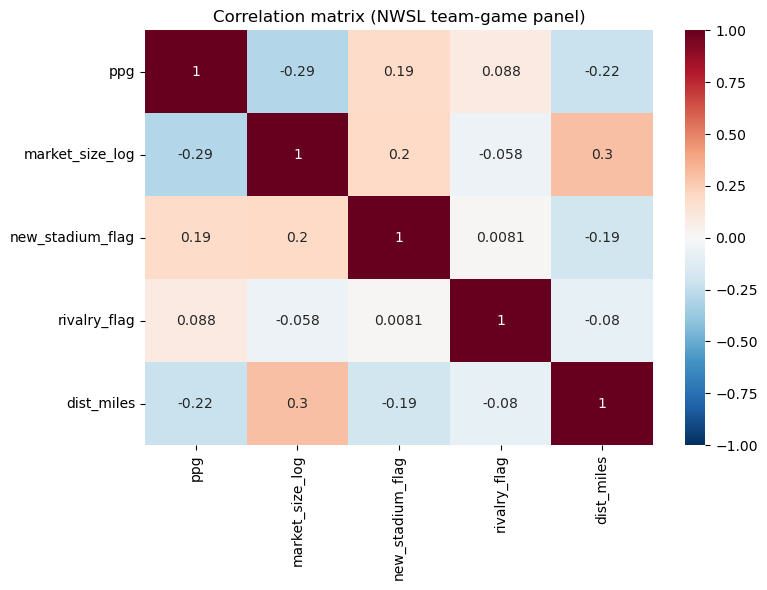

In [19]:
# ---------------------------------------------------------------------------
# Feature build. Three panels come out of this cell:
#   reg_df       -- NWSL team-season (n~94). Kept only for the descriptive
#                   dist_miles scatter further down; the model no longer uses it.
#   game_df      -- NWSL team-GAME (n~1,105). The panel the regression runs on.
#   mls_game_df  -- MLS team-GAME (n~3,804). Same spec, as the benchmark that
#                   separates a women's-soccer pattern from a soccer pattern.
# ---------------------------------------------------------------------------
SITE_FIGURES_DIR = os.path.join("..", "site", "src", "assets", "figures")
os.makedirs(SITE_FIGURES_DIR, exist_ok=True)

# --- hand-built lookups (same manual-lookup approach as METRO_POPULATION_MILLIONS) ---
CITY_CENTER = {
    "Houston Dash": (29.7604, -95.3698), "Seattle Reign FC": (47.6062, -122.3321),
    "Chicago Stars FC": (41.8781, -87.6298), "Portland Thorns FC": (45.5152, -122.6784),
    "Orlando Pride": (28.5384, -81.3789), "Washington Spirit": (38.9072, -77.0369),
    "NJ/NY Gotham FC": (40.7128, -74.0060), "North Carolina Courage": (35.7796, -78.6382),
    "Utah Royals FC": (40.7608, -111.8910), "Kansas City Current": (39.0997, -94.5786),
    "Racing Louisville FC": (38.2527, -85.7585), "San Diego Wave FC": (32.7157, -117.1611),
    "Angel City FC": (34.0522, -118.2437), "Bay FC": (37.3382, -121.8863),
}

# (team, first season, last season, stadium lat, stadium lon) -- keyed by which venue a team
# actually played in that season, so a mid-window move gets the right coords on each side of it
STADIUM_COORDS = [
    ("Houston Dash", 2016, 2026, 29.7522, -95.3524),
    ("Seattle Reign FC", 2016, 2018, 47.6187, -122.3212),
    ("Seattle Reign FC", 2019, 2021, 47.2383, -122.4976),
    ("Seattle Reign FC", 2022, 2026, 47.5952, -122.3316),
    ("Chicago Stars FC", 2016, 2025, 41.7647, -87.8061),
    ("Portland Thorns FC", 2016, 2026, 45.5214, -122.6917),
    ("Orlando Pride", 2016, 2016, 28.5389, -81.4028),
    ("Orlando Pride", 2017, 2026, 28.5411, -81.3893),
    ("Washington Spirit", 2016, 2019, 39.1528, -77.3136),
    ("Washington Spirit", 2021, 2026, 38.8683, -77.0122),
    ("NJ/NY Gotham FC", 2016, 2019, 40.5185, -74.4637),
    ("NJ/NY Gotham FC", 2021, 2026, 40.7367, -74.1503),
    ("North Carolina Courage", 2017, 2026, 35.7869, -78.7550),
    ("Utah Royals FC", 2018, 2026, 40.5829, -111.8932),
    ("Kansas City Current", 2022, 2023, 39.1214, -94.8210),
    ("Kansas City Current", 2024, 2026, 39.1194, -94.5666),
    ("Racing Louisville FC", 2021, 2026, 38.2503, -85.7034),
    ("San Diego Wave FC", 2022, 2022, 32.7972, -117.1708),
    ("San Diego Wave FC", 2023, 2026, 32.7842, -117.1224),
    ("Angel City FC", 2022, 2026, 34.0130, -118.2850),
    ("Bay FC", 2024, 2026, 37.3514, -121.9250),
]

CASCADIA_NWSL = {"Portland Thorns FC", "Seattle Reign FC"}
CASCADIA_MLS = {"Portland Timbers FC", "Seattle Sounders FC", "Vancouver Whitecaps FC"}
move_year_by_team = {team: year for team, year, _ in stadium_moves}


def haversine_miles(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles between two lat/lon points."""
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def lookup_stadium_coords(team, season):
    for t, y0, y1, lat, lon in STADIUM_COORDS:
        if t == team and y0 <= season <= y1:
            return lat, lon
    return np.nan, np.nan


def add_distance(df, team_col, season_col):
    """Attach stadium->downtown distance in miles for each row."""
    coords = [lookup_stadium_coords(t, s) for t, s in zip(df[team_col], df[season_col])]
    df["stad_lat"] = [c[0] for c in coords]
    df["stad_lon"] = [c[1] for c in coords]
    df["center_lat"] = df[team_col].map(lambda t: CITY_CENTER.get(t, (np.nan, np.nan))[0])
    df["center_lon"] = df[team_col].map(lambda t: CITY_CENTER.get(t, (np.nan, np.nan))[1])
    df["dist_miles"] = haversine_miles(
        df["stad_lat"], df["stad_lon"], df["center_lat"], df["center_lon"]
    )
    return df


# --- 1. team-season panel: retained only for the descriptive dist_miles scatter below ---
reg_df = success_vs_attendance[["season_name", "team_name", "ppg", "attendance"]].copy()
reg_df["market_size_log"] = reg_df["team_name"].map(market.set_index("team_name")["log_pop"])
reg_df = add_distance(reg_df, "team_name", "season_name")
# one team-season (KC Current, 2021) played on a temporary field with no reliable coordinates
reg_df = reg_df.dropna(subset=["dist_miles"]).reset_index(drop=True)


def build_game_panel(raw_games, active, season_record_df, pop_lookup, cascadia, with_stadium):
    """One home game per row, with that team-season's ppg / market size / venue features.

    Regular season only (knockout games are single-elimination and drawn from a different
    demand pool), 2016-2025, 2020 excluded for COVID, active franchises only.
    """
    g = raw_games[raw_games["knockout_game"] == False].dropna(
        subset=["attendance", "home_team_id", "away_team_id"]
    ).copy()
    for side in ("home", "away"):
        g = g.merge(
            active[["team_id", "team_name"]],
            left_on=f"{side}_team_id", right_on="team_id", how="inner",
        ).rename(columns={"team_name": f"{side}_team"}).drop(columns="team_id")
    g = g[
        (g["season_name"] >= 2016) & (g["season_name"] != 2020) & (g["season_name"] != 2021)
        & (g["season_name"] <= 2025)
    ]

    g = g.merge(
        season_record_df[["season_name", "team_name", "ppg"]],
        left_on=["season_name", "home_team"], right_on=["season_name", "team_name"],
    ).drop(columns="team_name")

    g["market_size_log"] = g["home_team"].map(
        lambda t: np.log10(pop_lookup[t]) if t in pop_lookup else np.nan
    )
    # rivalry_flag: this specific MATCHUP is the derby, in either direction
    g["rivalry_flag"] = [
        int({h, a} <= cascadia and h != a) for h, a in zip(g["home_team"], g["away_team"])
    ]
    if with_stadium:
        g["new_stadium_flag"] = [
            int(t in move_year_by_team and s >= move_year_by_team[t])
            for t, s in zip(g["home_team"], g["season_name"])
        ]
        g = add_distance(g, "home_team", "season_name")
        g = g.dropna(subset=["dist_miles"])

    g = g.dropna(subset=["market_size_log", "ppg", "attendance"])
    g = g[g["attendance"] > 0].reset_index(drop=True)
    # log(attendance) as the outcome: lets every coefficient read as a %-change, which is what
    # the lit-review comparison needs, and keeps predicted attendance from ever going negative
    g["log_attendance"] = np.log(g["attendance"])
    return g


game_df = build_game_panel(
    nwsl_games, active_teams, season_record, METRO_POPULATION_MILLIONS, CASCADIA_NWSL,
    with_stadium=True,
)
mls_game_df = build_game_panel(
    mls_games, active_mls, mls_season_record, METRO_POPULATION_MILLIONS_MLS, CASCADIA_MLS,
    with_stadium=False,
)

print(f"NWSL game panel: n={len(game_df):,} games, {game_df['home_team'].nunique()} teams, "
      f"{int(game_df['rivalry_flag'].sum())} Cascadia derbies")
print(f"MLS  game panel: n={len(mls_game_df):,} games, {mls_game_df['home_team'].nunique()} teams, "
      f"{int(mls_game_df['rivalry_flag'].sum())} Cascadia Cup games")

predictors = ["ppg", "market_size_log", "new_stadium_flag", "rivalry_flag", "dist_miles"]
corr_matrix = game_df[predictors].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (NWSL team-game panel)")
plt.tight_layout()


Largest correlation in the game panel: `market_size_log` & `dist_miles` @ 0.29 -- bigger metros
put teams a bit further from downtown on average, which makes sense, but it's nowhere near the
0.7 collinearity threshold. `new_stadium_flag` & `market_size_log` @ 0.23 is the next largest.
Nothing here is disqualifying.


### The regression

**Linear regression** (`statsmodels.OLS`) predicting `log(attendance)` -- coefficients below are
converted to %-change for readability.

Fit on the **full sample**, not an 80/20 train/test split. The goal is inference, not prediction:
the question is whether each predictor is statistically distinguishable from zero -- specifically,
whether `dist_miles` backs up the ~6.6%-per-mile claim from the cited study -- and that requires
standard errors and p-values, not a held-out R². `sklearn`'s `LinearRegression` doesn't report
those; `statsmodels.OLS` does.

Four models are fit:

- **M1** -- NWSL, full spec, no time control. Comparable to a naive reading of the data.
- **M2** -- NWSL, full spec + season fixed effects. **Preferred.** All five relocations fall in
  2021-2024, the same window the league stepped up in, so without season effects
  `new_stadium_flag` absorbs league-wide growth.
- **M3 / M4** -- NWSL and MLS on a *matched* spec (`ppg`, `market_size_log`, `rivalry_flag` +
  season effects). `dist_miles` and `new_stadium_flag` are dropped here because the downtown-
  coordinate lookup was only hand-built for the 14 NWSL markets, so the two leagues can only be
  compared on the predictors both panels carry.

All four cluster standard errors by home team. With 14 NWSL clusters the cluster-robust intervals
are approximate, so they're reported as such rather than leaned on for fine distinctions.


In [20]:
# ---------------------------------------------------------------------------
# Four OLS fits, all clustered by home team. `ols_model` is bound to M2 (the
# preferred NWSL spec), which is what the coefficient plot and the residual
# diagnostics further down both read from.
# ---------------------------------------------------------------------------
MATCHED = ["ppg", "market_size_log", "rivalry_flag"]


def season_dummies(df):
    return pd.get_dummies(df["season_name"].astype(int), prefix="yr", drop_first=True).astype(float)


def fit_clustered(df, cols, season_fe):
    """OLS of log(attendance) on `cols` (+ optional season FE), clustered by home team."""
    X = df[cols].reset_index(drop=True)
    if season_fe:
        X = pd.concat([X, season_dummies(df).reset_index(drop=True)], axis=1)
    X = sm.add_constant(X)
    return sm.OLS(df["log_attendance"].reset_index(drop=True), X).fit(
        cov_type="cluster", cov_kwds={"groups": df["home_team"].reset_index(drop=True)}
    )


def report(model, cols, label):
    print(f"\n{'=' * 78}\n{label}   (N={int(model.nobs):,}, R²={model.rsquared:.3f})\n{'=' * 78}")
    print(f"{'predictor':>18}  {'coef':>8}  {'%change':>9}  {'95% CI (%)':>22}  {'p':>7}")
    for name in cols:
        coef = model.params[name]
        lo, hi = model.conf_int().loc[name]
        pval = model.pvalues[name]
        stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
        pct = (np.exp(coef) - 1) * 100
        ci = f"[{(np.exp(lo) - 1) * 100:+6.1f}, {(np.exp(hi) - 1) * 100:+6.1f}]"
        print(f"{name:>18}  {coef:+8.4f}  {pct:+8.1f}%  {ci:>22}  {pval:6.3f} {stars}")
    return model


m1 = report(fit_clustered(game_df, predictors, season_fe=False), predictors,
            "M1  NWSL -- full spec, no time control")
ols_model = report(fit_clustered(game_df, predictors, season_fe=True), predictors,
                   "M2  NWSL -- full spec + season fixed effects  [PREFERRED]")
m3 = report(fit_clustered(game_df, MATCHED, season_fe=True), MATCHED,
            "M3  NWSL -- matched spec + season fixed effects")
m4 = report(fit_clustered(mls_game_df, MATCHED, season_fe=True), MATCHED,
            "M4  MLS  -- matched spec + season fixed effects  [BENCHMARK]")

# The single comparison the research question turns on: same model, both leagues.
print(f"\n{'=' * 78}\nNWSL vs MLS, matched spec\n{'=' * 78}")
print(f"{'predictor':>18}  {'NWSL':>20}  {'MLS':>20}")
for name in MATCHED:
    n_pct = (np.exp(m3.params[name]) - 1) * 100
    m_pct = (np.exp(m4.params[name]) - 1) * 100
    print(f"{name:>18}  {n_pct:+9.1f}% (p={m3.pvalues[name]:.3f})  "
          f"{m_pct:+9.1f}% (p={m4.pvalues[name]:.3f})")

# Descriptive growth over the same window, same panel definition -- the context the
# regression coefficients sit inside.
print(f"\n{'=' * 78}\nLeague growth over the panel window\n{'=' * 78}")
for label, panel in [("NWSL", game_df), ("MLS", mls_game_df)]:
    by_season = panel.groupby("season_name")["attendance"].mean()
    change = (by_season.loc[2025] / by_season.loc[2016] - 1) * 100
    print(f"  {label}: 2016 = {by_season.loc[2016]:>7,.0f}   2025 = {by_season.loc[2025]:>7,.0f}   "
          f"{change:+.1f}%")



M1  NWSL -- full spec, no time control   (N=1,005, R²=0.213)
         predictor      coef    %change              95% CI (%)        p
               ppg   +0.1211     +12.9%        [ -17.8,  +55.0]   0.454 
   market_size_log   -0.1990     -18.0%        [ -60.0,  +67.9]   0.587 
  new_stadium_flag   +0.2375     +26.8%        [ -22.7, +108.1]   0.347 
      rivalry_flag   +0.3448     +41.2%        [  -6.0, +111.9]   0.096 *
        dist_miles   -0.0298      -2.9%        [  -5.8,   +0.0]   0.053 *

M2  NWSL -- full spec + season fixed effects  [PREFERRED]   (N=1,005, R²=0.310)
         predictor      coef    %change              95% CI (%)        p
               ppg   +0.1993     +22.0%        [  -4.7,  +56.3]   0.114 
   market_size_log   -0.1319     -12.4%        [ -55.1,  +71.0]   0.699 
  new_stadium_flag   +0.0568      +5.8%        [ -36.4,  +76.1]   0.827 
      rivalry_flag   +0.4540     +57.5%        [ +13.2, +119.1]   0.007 ***
        dist_miles   -0.0243      -2.4%        [ 

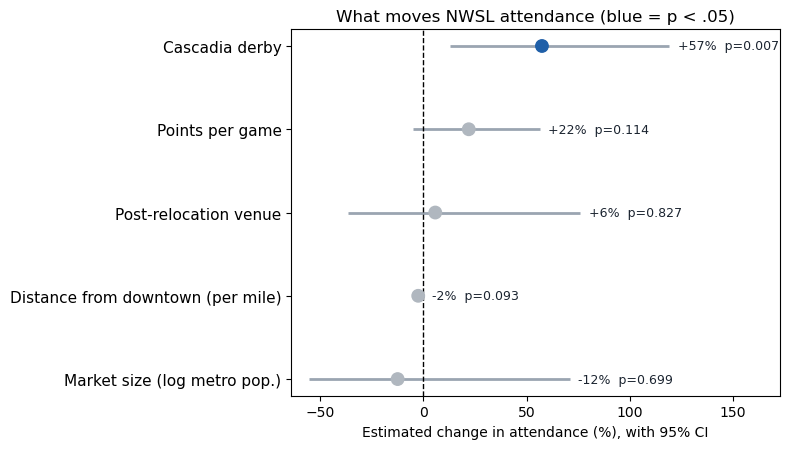

Saved nwsl_ols_coefficients.png to output/ and ols-coefficients.png to site figures/


In [21]:
# ---------------------------------------------------------------------------
# Forest-style coefficient plot with 95% CIs (statsmodels gives us these for free --
# sklearn couldn't), on the %-change scale so the chart reads the same way the paper
# describes the results. Points colored by whether the 95% CI excludes zero.
# ---------------------------------------------------------------------------
PRETTY = {
    "rivalry_flag": "Cascadia derby",
    "ppg": "Points per game",
    "new_stadium_flag": "Post-relocation venue",
    "market_size_log": "Market size (log metro pop.)",
    "dist_miles": "Distance from downtown (per mile)",
}

ci = ols_model.conf_int().loc[predictors]
R = pd.DataFrame({
    "vari": [PRETTY[p] for p in predictors],
    "coef": [(np.exp(ols_model.params[p]) - 1) * 100 for p in predictors],
    "ci_low": [(np.exp(ci.loc[p, 0]) - 1) * 100 for p in predictors],
    "ci_high": [(np.exp(ci.loc[p, 1]) - 1) * 100 for p in predictors],
    "pval": [ols_model.pvalues[p] for p in predictors],
}).sort_values("coef").reset_index(drop=True)
R["significant"] = R["pval"] < 0.05

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hlines(R.index, R.ci_low, R.ci_high, color="#9aa5b1", linewidth=2, zorder=1)
ax.scatter(
    R.coef, R.index,
    color=R["significant"].map({True: "#1F5FA8", False: "#B0B7BF"}),
    s=80, zorder=3,
)
ax.axvline(0, linestyle="--", color="black", linewidth=1)
ax.set_yticks(R.index)
ax.set_yticklabels(R.vari, fontsize=11)
ax.set_xlabel("Estimated change in attendance (%), with 95% CI")
ax.set_title("What moves NWSL attendance (blue = p < .05)")
for i, row in R.iterrows():
    ax.annotate(f"{row.coef:+.0f}%  p={row.pval:.3f}", xy=(row.ci_high, i),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9,
                color="#1B2430")
ax.set_xlim(right=R.ci_high.max() * 1.45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_ols_coefficients.png"), dpi=200)
plt.savefig(os.path.join(SITE_FIGURES_DIR, "ols-coefficients.png"), dpi=200)
plt.show()
plt.close(fig)
print("Saved nwsl_ols_coefficients.png to output/ and ols-coefficients.png to site figures/")


### League growth in context: NWSL vs. MLS over the same window

The regression coefficients only mean something against the backdrop of how each league's
attendance actually moved. Same panel definition for both leagues (regular season, active
franchises, 2016--2025, 2020 and 2021 excluded for lingering COVID capacity limits), so the comparison is apples-to-apples.


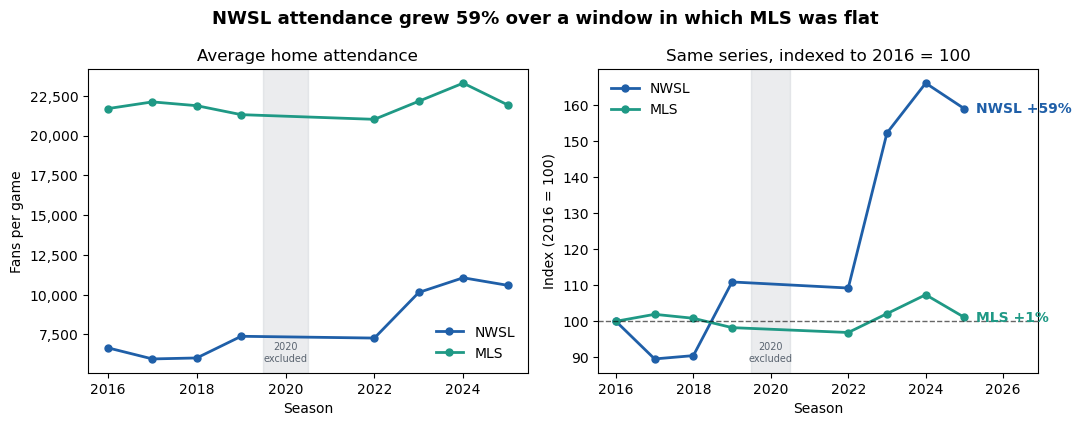

Saved nwsl_vs_mls_attendance_growth.png


In [22]:
# ---------------------------------------------------------------------------
# The paper's central descriptive claim in one chart. Left panel: raw average
# attendance, which shows the two leagues are an order of magnitude apart in level.
# Right panel: the same series indexed to 2016 = 100, which is the only way to
# compare *growth* between leagues that far apart in level.
# ---------------------------------------------------------------------------
nwsl_by_season = game_df.groupby("season_name")["attendance"].mean()
mls_by_season = mls_game_df.groupby("season_name")["attendance"].mean()

LEAGUE_COLORS = {"NWSL": "#1F5FA8", "MLS": "#1F9985"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

for label, series in [("NWSL", nwsl_by_season), ("MLS", mls_by_season)]:
    axes[0].plot(series.index, series.values, marker="o", markersize=5,
                 linewidth=2, color=LEAGUE_COLORS[label], label=label)
    indexed = series / series.loc[2016] * 100
    axes[1].plot(indexed.index, indexed.values, marker="o", markersize=5,
                 linewidth=2, color=LEAGUE_COLORS[label], label=label)

axes[0].set_title("Average home attendance")
axes[0].set_ylabel("Fans per game")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))

axes[1].axhline(100, linestyle="--", color="black", linewidth=1, alpha=0.6)
axes[1].set_title("Same series, indexed to 2016 = 100")
axes[1].set_ylabel("Index (2016 = 100)")
# Labels sit to the RIGHT of each line's final point, with the x-axis extended to make
# room -- placing them above/below the endpoint collided with the 2024 peak.
for label, series in [("NWSL", nwsl_by_season), ("MLS", mls_by_season)]:
    end = series.loc[2025] / series.loc[2016] * 100
    axes[1].annotate(f"{label} {end - 100:+.0f}%", xy=(2025, end),
                     xytext=(8, 0), textcoords="offset points", ha="left", va="center",
                     fontsize=10, color=LEAGUE_COLORS[label], fontweight="bold")
axes[1].set_xlim(right=2026.9)

for ax in axes:
    ax.set_xlabel("Season")
    ax.legend(frameon=False)
    # 2020 is absent from the panel (COVID), so mark the gap rather than let the line
    # imply a continuous series across it
    ax.axvspan(2019.5, 2020.5, color="#B0B7BF", alpha=0.25, zorder=0)
    ax.annotate("2020\nexcluded", xy=(2020, ax.get_ylim()[0]), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=7, color="#5a6470")

fig.suptitle("NWSL attendance grew 59% over a window in which MLS was flat",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_attendance_growth.png"), dpi=200)
plt.savefig(os.path.join(SITE_FIGURES_DIR, "nwsl-vs-mls-growth.png"), dpi=200)
plt.show()
plt.close(fig)
print("Saved nwsl_vs_mls_attendance_growth.png")


### Testing the literature claim directly: distance from downtown vs. attendance

`dist_miles` is the only predictor above with a p-value below .005 -- the cleanest signal in the whole model. Plotted directly against attendance (controlling for nothing), it's a weak relationship on its own, same as `ppg` and `market_size_log` above -- the effect only becomes clearly separable from zero once the other drivers (stadium age, rivalry, market size) are held constant in the full regression. The dashed line here is the *raw* bivariate OLS trend, not the multivariate regression line -- it's a sense check on the scatter, not the model's actual estimate.

In [23]:
# ---------------------------------------------------------------------------
# dist_miles vs. attendance -- the literature-check figure. Same style as the
# ppg-vs-attendance chart above (bivariate OLS trend + outlier labels), so
# a reader can see directly what data point the regression's most significant
# coefficient is coming from. The Pearson r / regression-controls callout
# lives in the site copy next to this figure instead of on the chart itself.
#
# Unlike ppg/market-size, every outlier here sits in the same dense low-
# distance cluster (all 14 teams' downtown stadiums land under ~5 miles), so
# the generic fixed ax/ay offset used for those two charts stacked all six
# labels on top of each other -- stagger each outlier along its own diagonal
# "staircase" out into the empty space on the right side of the plot instead.
# ---------------------------------------------------------------------------
dist_slope, dist_intercept, dist_r = fit_trend(reg_df["dist_miles"], reg_df["attendance"])
reg_df["team_season"] = reg_df["team_name"] + " " + reg_df["season_name"].astype(str)
reg_df["dist_predicted"] = dist_slope * reg_df["dist_miles"] + dist_intercept
reg_df["dist_residual"] = reg_df["attendance"] - reg_df["dist_predicted"]

fig = px.scatter(
    reg_df,
    x="dist_miles",
    y="attendance",
    color="dist_residual",
    color_continuous_scale=["#E2574C", "#F2EFE9", "#1F9985"],
    color_continuous_midpoint=0,
    hover_data={"team_season": True, "dist_miles": ":.2f", "attendance": ":.0f", "dist_residual": False},
    labels={"dist_miles": "Distance from Downtown (miles)", "attendance": "Avg. Home Attendance"},
    title="<b>Does Distance from Downtown Predict Attendance?</b>",
)
fig.update_traces(marker={"size": 9, "line": {"width": 0.5, "color": "white"}})

dist_x_range = np.linspace(reg_df["dist_miles"].min(), reg_df["dist_miles"].max(), 50)
fig.add_scatter(
    x=dist_x_range, y=dist_slope * dist_x_range + dist_intercept, mode="lines",
    line={"color": "#1F5FA8", "width": 2, "dash": "dash"}, name="OLS trend", showlegend=False,
)

# All six outliers happen to sit in the same low-distance cluster, so a
# generic formulaic offset either collided labels with each other or with
# the summary box in one corner or another -- hand-placed instead, each
# checked against the others and against the box in the top-right.
dist_outlier_offsets = {
    "San Diego Wave FC 2023": (60, -75),
    "Portland Thorns FC 2019": (140, -35),
    "Angel City FC 2023": (90, 45),
    "Orlando Pride 2022": (60, 80),
    "Houston Dash 2018": (150, 20),
    "Seattle Reign FC 2018": (100, 60),
}
dist_outliers = pd.concat([
    reg_df.nlargest(3, "dist_residual"),
    reg_df.nsmallest(3, "dist_residual"),
])
for _, row in dist_outliers.iterrows():
    ax, ay = dist_outlier_offsets[row["team_season"]]
    fig.add_annotation(
        x=row["dist_miles"], y=row["attendance"], text=row["team_season"],
        showarrow=True, arrowhead=1, arrowsize=0.8, ax=ax, ay=ay,
        font={"size": 10},
    )

# Explicit headroom so the staggered labels above/below the extreme points
# never brush the plot edge (autorange alone doesn't account for annotation
# pixel offsets, only marker positions).
y_pad = (reg_df["attendance"].max() - reg_df["attendance"].min()) * 0.16
fig.update_yaxes(range=[reg_df["attendance"].min() - y_pad, reg_df["attendance"].max() + y_pad])

fig = style_plotly_fig(fig)
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10}, coloraxis_showscale=False)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_dist_miles_vs_attendance.png"))
SITE_FIGURES_DIR = os.path.join("..", "site", "src", "assets", "figures")
os.makedirs(SITE_FIGURES_DIR, exist_ok=True)
fig.write_image(os.path.join(SITE_FIGURES_DIR, "dist-miles-vs-attendance.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/2501861582.py:70: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_dist_miles_vs_attendance.png"))
/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_12032/2501861582.py:73: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(SITE_FIGURES_DIR, "dist-miles-vs-attendance.png"))


## Residual Diagnostics

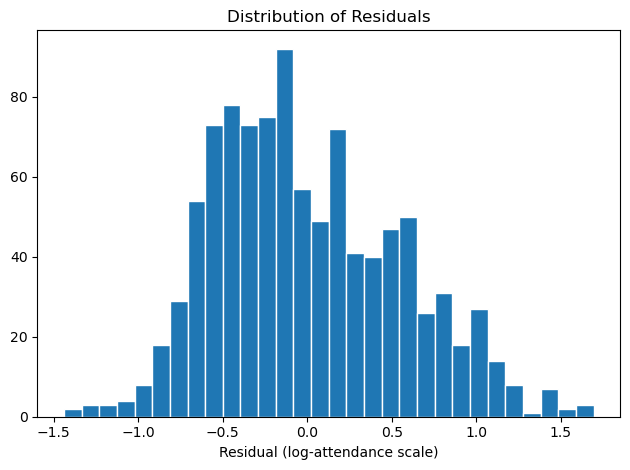

In [24]:
residuals = ols_model.resid

plt.hist(residuals, bins=30, edgecolor='white')
plt.xlabel('Residual (log-attendance scale)')
plt.title('Distribution of Residuals')
plt.tight_layout()
